In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import gaussian_filter1d

import paths as p
import utils

In [20]:
heatmap_dir = os.path.join(p.FIGURES_DIR, 'heatmaps')


In [3]:
units_vetted = pd.read_csv(os.path.join(p.LOGS_DIR, 'units_vetted.csv'), index_col=0).sort_values('unit_id')
sessions_vetted = pd.read_csv(os.path.join(p.LOGS_DIR, 'sessions_vetted.csv'), index_col=0).sort_values('num_units', ascending=False)

In [4]:
units_qc_all = pd.read_csv(p.LOGS_DIR / "qc_per_unit_with_pass_flags.csv")
units_qc = units_qc_all[units_qc_all['qc_pass_all'] == True]
units_per_session = units_qc.groupby('session_id').size().reset_index(name='unit_count')
sessions_vetted = sessions_vetted.merge(
    units_per_session[['session_id', 'unit_count']],
    how='left',
    left_on='id',
    right_on='session_id'
).rename(columns={'unit_count': 'unit_qc_pass_count'})

In [5]:
sessions_filtered = sessions_vetted[sessions_vetted['unit_qc_pass_count'] >= 60]
len(sessions_filtered)

7

In [6]:
time_step = 0.1

In [7]:
def get_trial_peak_positions_norm01(
    trial_spikes_df, trial_info,
    start_key='cue_on_time', end_key='decision_time',
    n_bins_norm=100, sigma=1
):
    """
    Returns:
        y_peak: (n_units_active,) array of peak positions in [0,1]
        unit_ids_used: (n_units_active,) array of unit_ids kept
    Skips units with no spikes in the [start,end] window.
    """
    t_start = trial_info.get(start_key, np.nan)
    t_end   = trial_info.get(end_key,   np.nan)

    # invalid window -> return empty
    if not (pd.notna(t_start) and pd.notna(t_end) and (t_end > t_start)):
        return np.array([]), np.array([])

    bin_edges = np.linspace(0.0, 1.0, n_bins_norm + 1)
    bin_w = bin_edges[1] - bin_edges[0]

    # warp spike times to [0,1] and clip
    df = trial_spikes_df.copy()
    df['norm_time'] = np.clip((df['trial_time'] - t_start) / (t_end - t_start), 0.0, 1.0)

    unit_ids = df['unit_id'].unique()
    y_peak = []
    unit_ids_used = []

    for uid in unit_ids:
        times = df.loc[df['unit_id'] == uid, 'norm_time'].to_numpy()
        if times.size == 0:
            continue
        counts, _ = np.histogram(times, bins=bin_edges)
        if counts.sum() == 0:
            continue

        # "rate" per normalized unit (scale irrelevant since we z-score per unit)
        rates = counts / bin_w
        rates_sm = gaussian_filter1d(rates, sigma=sigma)

        sd = rates_sm.std()
        if sd == 0:
            continue  # flat/no-variance -> skip this unit for peak analysis

        z = (rates_sm - rates_sm.mean()) / sd
        peak_bin = np.argmax(z)  # 0..n_bins_norm-1
        # convert to bin center in [0,1]
        peak_pos = (bin_edges[peak_bin] + bin_edges[peak_bin+1]) * 0.5

        y_peak.append(peak_pos)
        unit_ids_used.append(uid)

    if len(y_peak) == 0:
        return np.array([]), np.array([])

    # Order units by peak time (population trajectory from early->late)
    order = np.argsort(y_peak)
    y_peak = np.asarray(y_peak)[order]
    unit_ids_used = np.asarray(unit_ids_used)[order]

    return y_peak, unit_ids_used


def curvature_metrics_from_peaks(y_peak):
    """
    Input:
        y_peak: (N,) peak positions in [0,1], ordered by increasing peak time
    Returns a dict with:
        n, r2_lin, r2_quad, delta_r2, c_quad, concavity, resid_trend
    Notes:
        - x is unit rank normalized to [0,1]
        - c_quad is the quadratic coefficient (curvature term)
        - resid_trend is rank-correlation-like sign to capture residual skew
    """
    N = len(y_peak)
    if N < 8:  # too few units -> unstable curvature
        return dict(n=N, r2_lin=np.nan, r2_quad=np.nan, delta_r2=np.nan,
                    c_quad=np.nan, concavity='NA', resid_trend=np.nan)

    # x = unit index normalized to [0,1]
    x = np.linspace(0.0, 1.0, N)

    # Linear fit y = a + b x
    X_lin = np.column_stack([np.ones(N), x])
    beta_lin, _, _, _ = np.linalg.lstsq(X_lin, y_peak, rcond=None)
    yhat_lin = X_lin @ beta_lin

    # Quadratic fit y = a + b x + c x^2
    X_quad = np.column_stack([np.ones(N), x, x**2])
    beta_quad, _, _, _ = np.linalg.lstsq(X_quad, y_peak, rcond=None)
    yhat_quad = X_quad @ beta_quad

    # R^2
    ss_tot = np.sum((y_peak - y_peak.mean())**2)
    ss_res_lin = np.sum((y_peak - yhat_lin)**2)
    ss_res_quad = np.sum((y_peak - yhat_quad)**2)
    r2_lin = 1.0 - ss_res_lin / ss_tot if ss_tot > 0 else np.nan
    r2_quad = 1.0 - ss_res_quad / ss_tot if ss_tot > 0 else np.nan
    delta_r2 = r2_quad - r2_lin

    # Curvature term (c)
    c_quad = float(beta_quad[2])
    concavity = 'concave_up' if c_quad > 0 else ('concave_down' if c_quad < 0 else 'flat')

    # Residual trend: correlation between linear residuals and unit rank (sign only)
    resid = y_peak - yhat_lin
    # rank-based correlation (Spearman-like without scipy): corr(rank(resid), rank(x))
    rr = np.corrcoef(np.argsort(np.argsort(resid)), np.argsort(np.argsort(x)))[0,1]
    resid_trend = float(rr)

    return dict(n=N, r2_lin=float(r2_lin), r2_quad=float(r2_quad),
                delta_r2=float(delta_r2), c_quad=c_quad,
                concavity=concavity, resid_trend=resid_trend)

In [8]:
# single trial test
session_id = "RZ063_2025-03-07_str"
trial_id = 71

session_info = sessions_filtered.loc[sessions_filtered['id'] == session_id].iloc[0]
events, trials, units = utils.get_session_data(session_info['id'])
trial_info = trials.loc[trials['trial_id'] == trial_id].iloc[0]
trial_spikes_list = []
for idx, unit in units.items():
    trial_spikes = unit.loc[unit['trial_id'] == trial_id].copy()
    if not trial_spikes.empty:
        trial_spikes.loc[:, 'unit_id'] = idx
        trial_spikes_list.append(trial_spikes)
trial_spikes_df = pd.concat(trial_spikes_list)

In [9]:
y_peak, unit_ids_used = get_trial_peak_positions_norm01(
    trial_spikes_df, trial_info,
    start_key='cue_on_time', end_key='decision_time',
    n_bins_norm=100, sigma=1
)

metrics = curvature_metrics_from_peaks(y_peak)

# Example: write metric into filename or log
tw = round(trial_info['wait_length'], 2)
cid = session_info['id']
tid = trial_info['trial_id']
print(f"{cid} trial {tid} tw={tw}s  n={metrics['n']}  ΔR²={metrics['delta_r2']:.3f}  c={metrics['c_quad']:.3g}  {metrics['concavity']}")

RZ063_2025-03-07_str trial 71 tw=2.94s  n=117  ΔR²=0.185  c=-0.829  concave_down


In [10]:
y_peak.shape, unit_ids_used.shape, metrics

((117,),
 (117,),
 {'n': 117,
  'r2_lin': 0.1320697628674118,
  'r2_quad': 0.3172533383612015,
  'delta_r2': 0.18518357549378972,
  'c_quad': -0.8286445520898659,
  'concavity': 'concave_down',
  'resid_trend': -0.6861484511981297})

In [ ]:
session_id = "RZ063_2025-03-07_str"
session_info = sessions_filtered.loc[sessions_filtered['id'] == session_id].iloc[0]
events, trials, units = utils.get_session_data(session_info['id'])

curv_rows = []
for t, trial_info in trials.iterrows():
    trial_id = trial_info['trial_id']
    trial_spikes_list = []
    for idx, unit in units.items():
        trial_spikes = unit.loc[unit['trial_id'] == trial_id].copy()
        if not trial_spikes.empty:
            trial_spikes.loc[:, 'unit_id'] = idx
            trial_spikes_list.append(trial_spikes)
    trial_spikes_df = pd.concat(trial_spikes_list)
    y_peak, unit_ids_used = get_trial_peak_positions_norm01(
        trial_spikes_df, trial_info,
        start_key='cue_on_time', end_key='decision_time',
        n_bins_norm=100, sigma=1
    )

    metrics = curvature_metrics_from_peaks(y_peak)
    m = curvature_metrics_from_peaks(y_peak)
    m.update(dict(session_id=session_info['id'], trial_id=trial_info['trial_id'],
                  wait_len=trial_info['wait_length']))
    curv_rows.append(m)

In [ ]:
curv_df = pd.DataFrame(curv_rows)
# Example: pick top 25% by delta_r2
thr = curv_df['delta_r2'].quantile(0.75)
log_like = curv_df[curv_df['delta_r2'] >= thr]
linear_like = curv_df[curv_df['delta_r2'] <  thr]

In [ ]:
log_like

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(log_like['wait_len'], bins=20, alpha=0.7, label='log-like')
plt.hist(linear_like['wait_len'], bins=20, alpha=0.7, label='linear-like')
plt.xlabel('wait_len')
plt.ylabel('Count')
plt.legend()
plt.title('Wait Length Distribution: Log-like vs Linear-like')
plt.show()

In [ ]:
session_id = "RZ063_2025-03-07_str"
session_info = sessions_filtered.loc[sessions_filtered['id'] == session_id].iloc[0]
events, trials, units = utils.get_session_data(session_info['id'])

good_trials = trials[trials['good']]
sorted_trials = good_trials.sort_values('wait_length')
mid = len(sorted_trials) // 2
half = 10
median_20_trials = sorted_trials.iloc[max(0, mid - half):mid + half]

mid_trial = median_20_trials.iloc[half]  # pick the middle one

trial_id = mid_trial['trial_id']
trial_spikes_list = []
for idx, unit in units.items():
    trial_spikes = unit.loc[unit['trial_id'] == trial_id].copy()
    if not trial_spikes.empty:
        trial_spikes.loc[:, 'unit_id'] = idx
        trial_spikes_list.append(trial_spikes)
trial_spikes_df = pd.concat(trial_spikes_list)

In [ ]:
unit_ids = trial_spikes_df['unit_id'].unique()
heatmap_data = []
for unit_id in unit_ids:
    trial_spikes_unit = trial_spikes_df.loc[trial_spikes_df['unit_id'] == unit_id]
    bounds = (0, trial_info['trial_length'])
    bin_edges = np.arange(bounds[0] - time_step, bounds[1] + 2*time_step, time_step)
    counts = np.histogram(trial_spikes_unit['trial_time'], bins=bin_edges)[0]
    rates = counts / time_step
    rates_smoothed = gaussian_filter1d(rates, sigma=1)
    normalized_rates = (rates_smoothed - rates_smoothed.mean()) / rates_smoothed.std()
    heatmap_data.append(normalized_rates)

heatmap_data = np.array(heatmap_data)
max_bin_indices = np.argmax(heatmap_data, axis=1)
sorted_indices = np.argsort(max_bin_indices)
sorted_heatmap = heatmap_data[sorted_indices]

In [ ]:
mid_trial

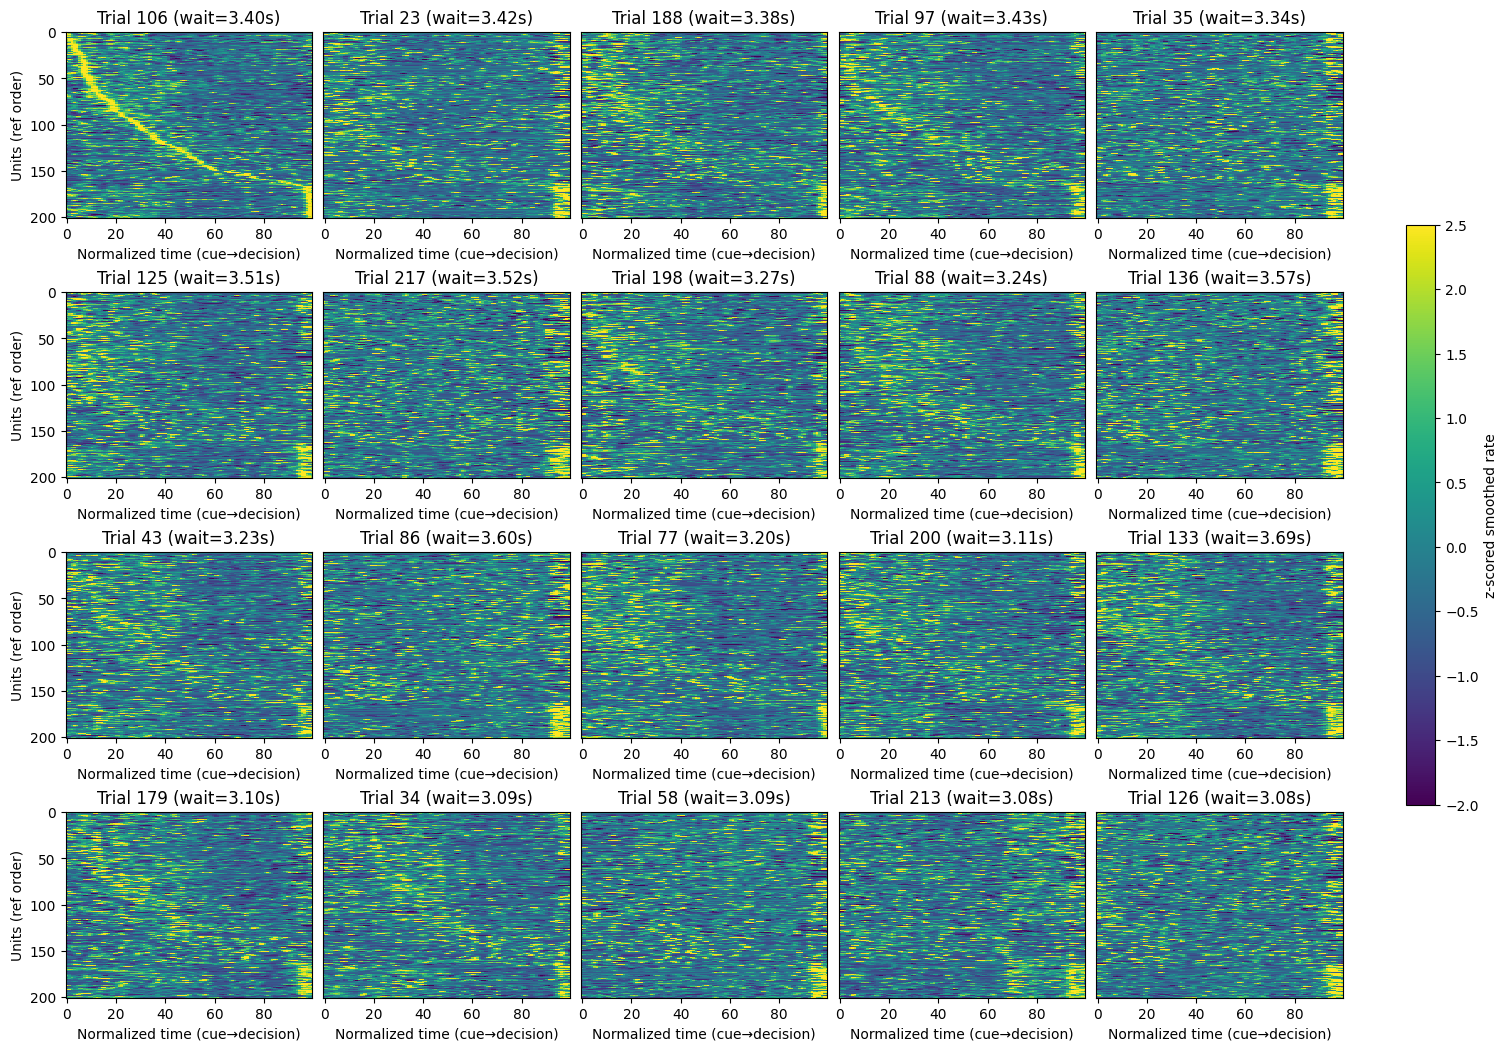

In [22]:
# --- Params ---
n_bins = 100        # number of bins in the normalized window [0,1]
sigma = 1           # smoothing for gaussian_filter1d
vmin, vmax = -2.0, 2.5  # fixed color scale across panels

# --- Choose reference trial and 19 most similar by wait_length ---
session_id = "RZ061_2025-03-12_str"
session_info = sessions_filtered.loc[sessions_filtered['id'] == session_id].iloc[0]
events, trials, units = utils.get_session_data(session_info['id'])

reference_trial_id = 106  # <-- set your reference trial_id here
reference_trial = trials.loc[trials['trial_id'] == reference_trial_id].iloc[0]
reference_wait = reference_trial['wait_length']

# Compute absolute difference in wait_length for all trials (including non-good)
trials['wait_diff'] = np.abs(trials['wait_length'] - reference_wait)

# Exclude the reference trial itself, then get 19 closest
other_trials = trials[trials['trial_id'] != reference_trial_id].copy()
nearest_19 = other_trials.nsmallest(19, 'wait_diff')

# Combine reference + 19 nearest, reference first
plot_trials = pd.concat([reference_trial.to_frame().T, nearest_19], ignore_index=True)
plot_trials = plot_trials.reset_index(drop=True)

# --- Helpers for normalized time ---
def normalized_bin_edges(n_bins):
    # [0,1] inclusive edges for histogram
    return np.linspace(0.0, 1.0, n_bins + 1)

def to_normalized_times(spike_times, cue_on, decision):
    """Map absolute trial_time -> normalized [0,1] window; drop outside-window spikes."""
    dur = float(decision) - float(cue_on)
    if dur <= 0:
        # invalid window; return empty array
        return np.array([], dtype=float)
    norm = (spike_times - float(cue_on)) / dur
    return norm[(norm >= 0.0) & (norm <= 1.0)]

def zscore_safe(arr):
    mu = arr.mean()
    sd = arr.std()
    if sd > 0:
        return (arr - mu) / sd
    return np.zeros_like(arr)

bin_edges_norm = normalized_bin_edges(n_bins)

# --- Build unit order on the reference trial using normalized cue->decision window ---
cue_ref = float(reference_trial['cue_on_time'])
dec_ref = float(reference_trial['decision_time'])
if dec_ref - cue_ref <= 0:
    raise ValueError(f"Reference trial {reference_trial_id} has invalid cue->decision window.")

# gather spikes for the reference trial
ts_list = []
for uid, df in units.items():
    d = df.loc[df['trial_id'] == reference_trial_id].copy()
    if not d.empty:
        d.loc[:, 'unit_id'] = uid
        ts_list.append(d)
if not ts_list:
    raise ValueError("Reference trial has no spikes across all units.")

ref_trial_spikes = pd.concat(ts_list, ignore_index=True)
unit_ids = ref_trial_spikes['unit_id'].unique()

H = []
for uid in unit_ids:
    u_abs = ref_trial_spikes.loc[ref_trial_spikes['unit_id'] == uid, 'trial_time'].to_numpy()
    u_norm = to_normalized_times(u_abs, cue_ref, dec_ref)
    counts, _ = np.histogram(u_norm, bins=bin_edges_norm)
    rates = counts * (n_bins)  # optional: scale to ~per-unit-time; any constant cancels in z
    rates_sm = gaussian_filter1d(rates.astype(float), sigma=sigma)
    H.append(zscore_safe(rates_sm))

H = np.vstack(H) if len(H) else np.zeros((0, n_bins))
peak_bins = np.argmax(H, axis=1) if H.size else np.array([], dtype=int)
sorted_idx = np.argsort(peak_bins)
unit_order = unit_ids[sorted_idx]  # order defined on normalized reference trial

# --- Plot the 20 trials in the same normalized order ---
n_panels = len(plot_trials)
n_cols = 5
n_rows = int(np.ceil(n_panels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2.6*n_rows), constrained_layout=True)
axes = np.ravel(axes) if n_panels > 1 else [axes]

for k, trial in enumerate(plot_trials.itertuples(index=False)):
    trial_id = trial.trial_id
    cue = float(trial.cue_on_time)
    dec = float(trial.decision_time)

    if dec - cue <= 0:
        axes[k].axis('off')
        axes[k].set_title(f"Trial {trial_id}\n(invalid cue→decision)")
        continue

    # collect spikes for this trial
    ts_list = []
    for uid, df in units.items():
        d = df.loc[df['trial_id'] == trial_id].copy()
        if not d.empty:
            d.loc[:, 'unit_id'] = uid
            ts_list.append(d)
    if not ts_list:
        axes[k].axis('off')
        axes[k].set_title(f"Trial {trial_id}\n(no spikes)")
        continue

    tr_spikes = pd.concat(ts_list, ignore_index=True)

    # heatmap rows in the reference-trial unit order, normalized to this trial's cue->decision
    rows = []
    for uid in unit_order:
        u_abs = tr_spikes.loc[tr_spikes['unit_id'] == uid, 'trial_time'].to_numpy()
        u_norm = to_normalized_times(u_abs, cue, dec)
        counts, _ = np.histogram(u_norm, bins=bin_edges_norm)
        rates = counts * (n_bins)
        rates_sm = gaussian_filter1d(rates.astype(float), sigma=sigma)
        rows.append(zscore_safe(rates_sm))

    HM = np.vstack(rows) if len(rows) else np.zeros((0, n_bins))
    im = axes[k].imshow(HM, aspect='auto', interpolation='nearest',
                        cmap='viridis', vmin=vmin, vmax=vmax)
    axes[k].set_title(f"Trial {trial_id} (wait={trial.wait_length:.2f}s)")
    axes[k].set_xlabel('Normalized time (cue→decision)')
    if k % n_cols == 0:
        axes[k].set_ylabel('Units (ref order)')
    else:
        axes[k].set_yticks([])

# hide unused axes
for ax in axes[n_panels:]:
    ax.axis('off')

# single colorbar
cbar = fig.colorbar(im, ax=axes[:n_panels], shrink=0.6)
cbar.set_label('z-scored smoothed rate')

# Save figure to a path based on session and reference trial
save_path = f"{heatmap_dir}/heatmap_{session_id}_reftrial{reference_trial_id}.png"
plt.savefig(save_path)

In [ ]:
# --- Plot 20 trials with neuron order enforced (concordance by order) ---

n_panels = len(median_20_trials)
n_cols = 5
n_rows = int(np.ceil(n_panels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2.6*n_rows), constrained_layout=True)
axes = np.ravel(axes) if n_panels > 1 else [axes]

for k, trial in enumerate(median_20_trials.itertuples(index=False)):
    trial_id = trial.trial_id
    cue = float(trial.cue_on_time)
    dec = float(trial.decision_time)

    if dec - cue <= 0:
        axes[k].axis('off')
        axes[k].set_title(f"Trial {trial_id}\n(invalid cue→decision)")
        continue

    # collect spikes for this trial
    ts_list = []
    for uid, df in units.items():
        d = df.loc[df['trial_id'] == trial_id].copy()
        if not d.empty:
            d.loc[:, 'unit_id'] = uid
            ts_list.append(d)
    if not ts_list:
        axes[k].axis('off')
        axes[k].set_title(f"Trial {trial_id}\n(no spikes)")
        continue

    tr_spikes = pd.concat(ts_list, ignore_index=True)

    # build heatmap rows in the reference unit order
    rows = []
    for uid in unit_order:
        u_abs = tr_spikes.loc[tr_spikes['unit_id'] == uid, 'trial_time'].to_numpy()
        u_norm = to_normalized_times(u_abs, cue, dec)
        counts, _ = np.histogram(u_norm, bins=bin_edges_norm)
        rates = counts * (n_bins)
        rates_sm = gaussian_filter1d(rates.astype(float), sigma=sigma)
        if u_abs.size > 0:
            rows.append(zscore_safe(rates_sm))
        else:
            rows.append(np.full(n_bins, np.nan))  # or zeros if you prefer

    HM = np.vstack(rows) if len(rows) else np.zeros((0, n_bins))
    im = axes[k].imshow(HM, aspect='auto', interpolation='nearest',
                        cmap='viridis', vmin=vmin, vmax=vmax)
    axes[k].set_title(f"Trial {trial_id} (wait={trial.wait_length:.2f}s)")
    axes[k].set_xlabel('Normalized time (cue→decision)')
    if k % n_cols == 0:
        axes[k].set_ylabel('Units (median-order)')
    else:
        axes[k].set_yticks([])

# hide unused axes
for ax in axes[n_panels:]:
    ax.axis('off')

# single colorbar
cbar = fig.colorbar(im, ax=axes[:n_panels], shrink=0.6)
cbar.set_label('z-scored smoothed rate')

plt.show()

In [ ]:
# --- Find neurons with matching order of peak bins in two trials ---

trial_ids = [192, 165]
trial_infos = [median_20_trials[median_20_trials['trial_id'] == tid].iloc[0] for tid in trial_ids]
cue_times = [float(trial['cue_on_time']) for trial in trial_infos]
dec_times = [float(trial['decision_time']) for trial in trial_infos]

# Collect spikes for each trial
spikes = []
for tid in trial_ids:
    ts_list = []
    for uid, df in units.items():
        d = df.loc[df['trial_id'] == tid].copy()
        if not d.empty:
            d.loc[:, 'unit_id'] = uid
            ts_list.append(d)
    spikes.append(pd.concat(ts_list, ignore_index=True))

# Get unit_ids present in both trials
unit_ids_0 = set(spikes[0]['unit_id'].unique())
unit_ids_1 = set(spikes[1]['unit_id'].unique())
common_units = np.array(sorted(unit_ids_0 & unit_ids_1))

# For each trial, get the order of units by peak bin
def get_peak_order(tr_spikes, cue, dec, unit_ids):
    peak_bins = []
    for uid in unit_ids:
        u_abs = tr_spikes.loc[tr_spikes['unit_id'] == uid, 'trial_time'].to_numpy()
        u_norm = to_normalized_times(u_abs, cue, dec)
        counts, _ = np.histogram(u_norm, bins=bin_edges_norm)
        rates = counts * n_bins
        rates_sm = gaussian_filter1d(rates.astype(float), sigma=sigma)
        peak_bins.append(np.argmax(rates_sm))
    peak_bins = np.array(peak_bins)
    order = np.argsort(peak_bins)
    return unit_ids[order], peak_bins[order]

# Get peak order for both trials, only for common units
order0, peaks0 = get_peak_order(spikes[0], cue_times[0], dec_times[0], common_units)
order1, peaks1 = get_peak_order(spikes[1], cue_times[1], dec_times[1], common_units)

# Find the largest subset where the order is identical
def longest_common_order(orderA, orderB):
    # Find indices where orderA == orderB in the same order
    mask = orderA == orderB
    # If not all match, try all permutations (brute force for small N)
    if np.array_equal(orderA, orderB):
        return orderA
    # Otherwise, find the largest subset with matching order
    from itertools import combinations
    N = len(orderA)
    for k in range(N, 0, -1):
        for idxs in combinations(range(N), k):
            if np.array_equal(orderA[list(idxs)], orderB[list(idxs)]):
                return orderA[list(idxs)]
    return np.array([])

matching_units = longest_common_order(order0, order1)

print("Matching units in same order:", matching_units)

In [ ]:
# --- Approximate: Keep only neurons in trial 165 that respect the order of trial 192 ---

ref_trial_id = 58
other_trial_id = 104

# Get trial info
ref_info = median_20_trials[median_20_trials['trial_id'] == ref_trial_id].iloc[0]
other_info = median_20_trials[median_20_trials['trial_id'] == other_trial_id].iloc[0]
cue_ref, dec_ref = float(ref_info['cue_on_time']), float(ref_info['decision_time'])
cue_other, dec_other = float(other_info['cue_on_time']), float(other_info['decision_time'])

# Collect spikes for both trials
def get_spikes(trial_id):
    ts_list = []
    for uid, df in units.items():
        d = df.loc[df['trial_id'] == trial_id].copy()
        if not d.empty:
            d.loc[:, 'unit_id'] = uid
            ts_list.append(d)
    return pd.concat(ts_list, ignore_index=True)

spikes_ref = get_spikes(ref_trial_id)
spikes_other = get_spikes(other_trial_id)

# Get common units
unit_ids_ref = set(spikes_ref['unit_id'].unique())
unit_ids_other = set(spikes_other['unit_id'].unique())
common_units = np.array(sorted(unit_ids_ref & unit_ids_other))

# Get peak order for reference trial
def get_peak_order(tr_spikes, cue, dec, unit_ids):
    peak_bins = []
    for uid in unit_ids:
        u_abs = tr_spikes.loc[tr_spikes['unit_id'] == uid, 'trial_time'].to_numpy()
        u_norm = to_normalized_times(u_abs, cue, dec)
        counts, _ = np.histogram(u_norm, bins=bin_edges_norm)
        rates = counts * n_bins
        rates_sm = gaussian_filter1d(rates.astype(float), sigma=sigma)
        peak_bins.append(np.argmax(rates_sm))
    peak_bins = np.array(peak_bins)
    order = np.argsort(peak_bins)
    return unit_ids[order], peak_bins[order]

ref_order, ref_peaks = get_peak_order(spikes_ref, cue_ref, dec_ref, common_units)
other_order, other_peaks = get_peak_order(spikes_other, cue_other, dec_other, common_units)

# For each neuron, check if the order of peak bins in the other trial is consistent with the reference
def is_order_respected(ref_order, other_order):
    # Map unit id to its position in the other trial's order
    pos_in_other = {uid: i for i, uid in enumerate(other_order)}
    respected = []
    for i, uid_i in enumerate(ref_order):
        for j in range(i+1, len(ref_order)):
            uid_j = ref_order[j]
            # If neuron i comes before neuron j in ref, it must also come before in other
            if pos_in_other[uid_i] > pos_in_other[uid_j]:
                break
        else:
            respected.append(uid_i)
    return np.array(respected)

respected_units = is_order_respected(ref_order, other_order)

print("Neurons in trial 165 that respect the order of trial 192:", respected_units)

In [ ]:
ref_order

In [ ]:
# --- Plot respected units for both trials using the reference order ---
# This version ensures the respected units are plotted in the reference order, and handles empty/NaN rows robustly.

respected_ref_order = [uid for uid in ref_order if uid in respected_units]
if len(respected_ref_order) == 0:
    print("No respected units found for plotting.")
else:
    def build_heatmap(tr_spikes, cue, dec, unit_order):
        rows = []
        for uid in unit_order:
            u_abs = tr_spikes.loc[tr_spikes['unit_id'] == uid, 'trial_time'].to_numpy()
            u_norm = to_normalized_times(u_abs, cue, dec)
            if u_norm.size == 0 or np.all(np.isnan(u_norm)):
                rows.append(np.full(n_bins, np.nan))
                continue
            counts, _ = np.histogram(u_norm, bins=bin_edges_norm)
            rates = counts * n_bins
            rates_sm = gaussian_filter1d(rates.astype(float), sigma=sigma)
            if np.all(rates_sm == 0):
                rows.append(np.full(n_bins, np.nan))
            else:
                rows.append(zscore_safe(rates_sm))
        return np.vstack(rows) if len(rows) else np.zeros((0, n_bins))

    HM_ref = build_heatmap(spikes_ref, cue_ref, dec_ref, respected_ref_order)
    HM_other = build_heatmap(spikes_other, cue_other, dec_other, respected_ref_order)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
    vmin, vmax = -2.0, 2.5

    im0 = axes[0].imshow(HM_ref, aspect='auto', interpolation='nearest', cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0].set_title(f"Reference Trial {ref_trial_id}")
    axes[0].set_xlabel('Normalized time (cue→decision)')
    axes[0].set_ylabel('Respected units (ref order)')
    axes[0].set_yticks([])

    im1 = axes[1].imshow(HM_other, aspect='auto', interpolation='nearest', cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1].set_title(f"Other Trial {other_trial_id}")
    axes[1].set_xlabel('Normalized time (cue→decision)')
    axes[1].set_yticks([])

    cbar = fig.colorbar(im0, ax=axes, shrink=0.7)
    cbar.set_label('z-scored smoothed rate')

    plt.suptitle(f"Respected units (N={len(respected_ref_order)})\nOrder fixed by reference trial {ref_trial_id}")
    plt.show()